In [1]:
%load_ext autoreload

## Ileum dataset

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [3]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/25cc19dd-81eb-4e79-8820-86ff4cfb88b1_updated.h5ad",
)

In [4]:
adata

AnnData object with n_obs × n_vars = 201072 × 28923
    obs: 'biosample_id', 'n_genes', 'n_counts', 'Type', 'donor_id', 'Layer', 'Celltype', 'organism_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'age group', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_name'

In [5]:
adata.X = adata.X.tocsr()

In [6]:
adata.var.index = adata.var.feature_name.str.split("_").str[0]
adata = adata[:, ~adata.var.index.duplicated()]

In [7]:
adata_macrophages = adata[
    adata.obs.Celltype.isin(
        [
            "Macrophages",
            "Macrophages LYVE1",
            "Macrophages CCL3 CCL4",
            "Macrophages CXCL9 CXCL10",
            "Macrophages PLA2G2D"
        ]
    )
].copy()

In [40]:
adata_macrophages

AnnData object with n_obs × n_vars = 29603 × 28870
    obs: 'biosample_id', 'n_genes', 'n_counts', 'Type', 'donor_id', 'Layer', 'Celltype', 'organism_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'age group', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'Celltype_colors', 'donor_id_colors'
    obsm: 'X_pca', 'X_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [8]:
%autoreload
from pairot.de_testing.testing import calc_pseudobulk_stats
from pairot.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [9]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_macrophages,
    cluster_label="Celltype",
    sample_label="biosample_id"
)

R[write to console]: data.table 1.15.4 using 8 threads (see ?getDTthreads).  
R[write to console]: Latest news: r-datatable.com

Calculating AVA AUROC scores: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:23<00:00,  2.37s/it]


In [10]:
res = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.0,
        aucroc_threshold=0.6,
        adj_pval_threshold=0.05
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.0,
        aucroc_threshold=0.6,
        adj_pval_threshold=0.05
    ),
    overlap_threshold=0.3,
    n_genes_ova=None,
    n_genes_ava=None
)

/vol/data/git/dataset-similarity/datasim/utils.py:67: UserWarning: No marker genes provided for Macrophages and Macrophages CCL3 CCL4. Setting overlap to 0.
  warnings.warn(
/vol/data/git/dataset-similarity/datasim/utils.py:67: UserWarning: No marker genes provided for Macrophages and Macrophages LYVE1. Setting overlap to 0.
  warnings.warn(
/vol/data/git/dataset-similarity/datasim/utils.py:67: UserWarning: No marker genes provided for Macrophages and Macrophages. Setting overlap to 0.
  warnings.warn(
/vol/data/git/dataset-similarity/datasim/utils.py:67: UserWarning: No marker genes provided for Macrophages and Macrophages CXCL9 CXCL10. Setting overlap to 0.
  warnings.warn(
/vol/data/git/dataset-similarity/datasim/utils.py:67: UserWarning: No marker genes provided for Macrophages and Macrophages PLA2G2D. Setting overlap to 0.
  warnings.warn(


In [11]:
from IPython.display import display

In [12]:
for cluster in np.unique(adata_macrophages.obs.Celltype):
    df = res[cluster]
    df = df.head(20)
    print(cluster)
    display(
        df.style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()

Macrophages


,logFC,adj.P.Val,auroc,reference
ID,,,,



Macrophages CCL3 CCL4


,logFC,adj.P.Val,auroc,reference
ID,,,,
PTGS2,2.39,0.000,0.68,['all']
HES1,2.16,0.000,0.72,['all']
FOSB,2.13,0.000,0.80,['all']
RGS1,2.11,0.000,0.81,['all']
NR4A2,2.07,0.000,0.74,['all']
FOS,1.98,0.000,0.85,['all']
IL8,1.97,0.000,0.68,['all']
IL1B,1.96,0.000,0.69,['all']
PRDM1,1.94,0.000,0.70,['all']



Macrophages CXCL9 CXCL10


,logFC,adj.P.Val,auroc,reference
ID,,,,
CXCL10,3.64,0.000,0.81,['all']
CXCL9,3.00,0.000,0.77,['all']
GBP1,2.46,0.000,0.70,['all']



Macrophages LYVE1


,logFC,adj.P.Val,auroc,reference
ID,,,,
RNASE1,3.59,0.000,0.76,['all']
F13A1,3.03,0.000,0.72,['all']
EGR1,2.56,0.000,0.61,['all']
LYVE1,2.49,0.000,0.62,['all']
A2M,2.22,0.000,0.62,['all']
FOS,2.17,0.000,0.61,['all']
FOLR2,2.13,0.000,0.68,['all']
CCL18,2.09,0.000,0.65,['all']
PLTP,1.81,0.000,0.61,['all']



Macrophages PLA2G2D


,logFC,adj.P.Val,auroc,reference
ID,,,,
MMP9,2.81,0.000,0.72,['all']
PTGDS,2.65,0.000,0.72,['all']
PLA2G2D,2.30,0.000,0.69,['all']
ATOX1,1.68,0.000,0.74,['all']
CAPG,1.64,0.000,0.68,['all']
LGALS2,1.46,0.000,0.66,['all']
APOE,1.41,0.000,0.68,['all']
IL18,1.38,0.000,0.63,['all']
LYZ,0.87,0.000,0.65,['all']


In [39]:
# markers = ["LYVE1", "CCL3", "CCL4", "FOLR2"]
markers = ["CCL3", "CCL4", "AREG", "CD83", "CXCL2", "CXCL3", "IL1B", "NAMPT", "PLAUR", "SRGN", "THBS1"]

for cluster in np.unique(adata_macrophages.obs.Celltype):
    df = res[cluster]
    df.index.name = "ID"
    print(cluster)
    display(
        df
        .reset_index()
        .query(f'`ID` in {markers}')
        .style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()


Macrophages


,ID,logFC,adj.P.Val,auroc,reference



Macrophages CCL3 CCL4


,ID,logFC,adj.P.Val,auroc,reference
7,IL1B,1.96,0.000,0.69,['all']
12,CXCL3,1.87,0.000,0.64,['all']
19,CCL3,1.79,0.000,0.76,['all']
20,CXCL2,1.76,0.000,0.66,['all']
28,CCL4,1.69,0.000,0.71,['all']
29,NAMPT,1.68,0.000,0.72,['all']
44,PLAUR,1.51,0.000,0.66,['all']
45,CD83,1.50,0.000,0.72,['all']
66,THBS1,1.33,0.000,0.61,['all']
359,SRGN,0.74,0.000,0.84,['all']



Macrophages CXCL9 CXCL10


,ID,logFC,adj.P.Val,auroc,reference



Macrophages LYVE1


,ID,logFC,adj.P.Val,auroc,reference



Macrophages PLA2G2D


,ID,logFC,adj.P.Val,auroc,reference


## Update clustering

In [14]:
import harmonypy

In [15]:
adata_macrophages

AnnData object with n_obs × n_vars = 29603 × 28870
    obs: 'biosample_id', 'n_genes', 'n_counts', 'Type', 'donor_id', 'Layer', 'Celltype', 'organism_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'age group', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_name'

In [16]:
adata_macrophages.raw = adata_macrophages.copy()

In [17]:
sc.pp.normalize_total(adata_macrophages)
sc.pp.log1p(adata_macrophages)
sc.pp.highly_variable_genes(adata_macrophages)
sc.pp.pca(adata_macrophages)

In [28]:
RUN_HARMONY = True

if RUN_HARMONY:
    ho = harmonypy.run_harmony(
        adata_macrophages.obsm["X_pca"], 
        adata_macrophages.obs, 
        ["donor_id"],
        max_iter_harmony=100
    )
    adata_macrophages.obsm["X_harmony"] = ho.Z_corr.T
    sc.pp.neighbors(adata_macrophages, use_rep="X_harmony")
else:
    sc.pp.neighbors(adata_macrophages)


2025-04-29 15:57:43,566 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-29 15:57:54,059 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-29 15:57:54,145 - harmonypy - INFO - Iteration 1 of 100
2025-04-29 15:58:01,231 - harmonypy - INFO - Iteration 2 of 100
2025-04-29 15:58:08,313 - harmonypy - INFO - Converged after 2 iterations


In [29]:
sc.tl.umap(adata_macrophages)

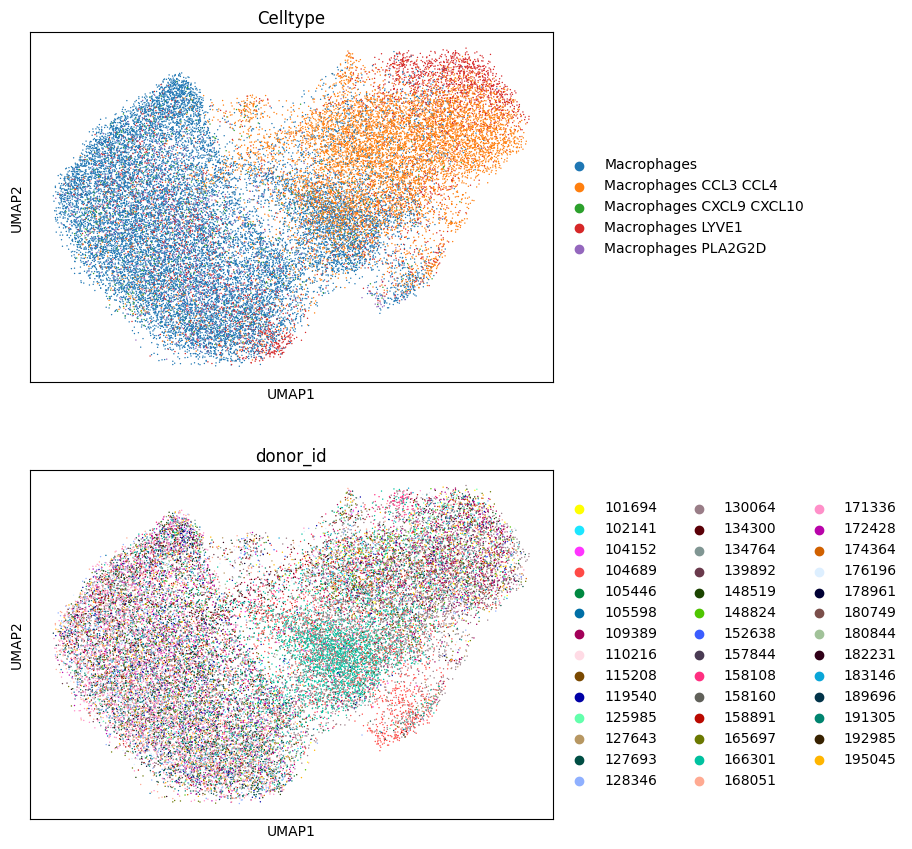

In [30]:
sc.pl.umap(adata_macrophages, color=["Celltype", "donor_id"], ncols=1)

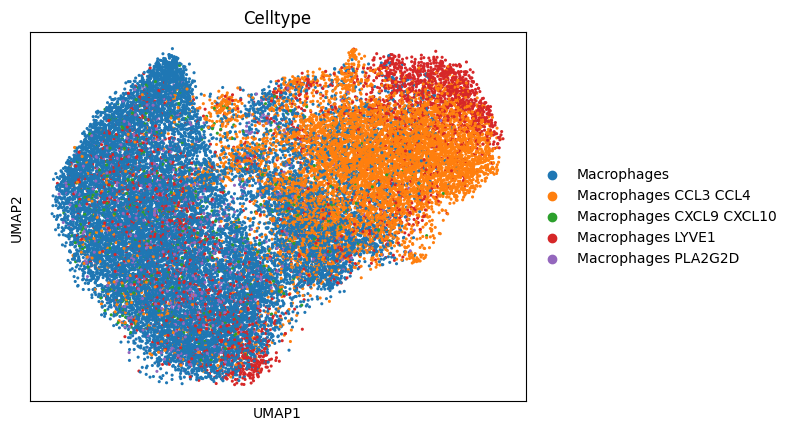

In [21]:
sc.pl.umap(adata_macrophages, color=["Celltype"], ncols=1, size=20)

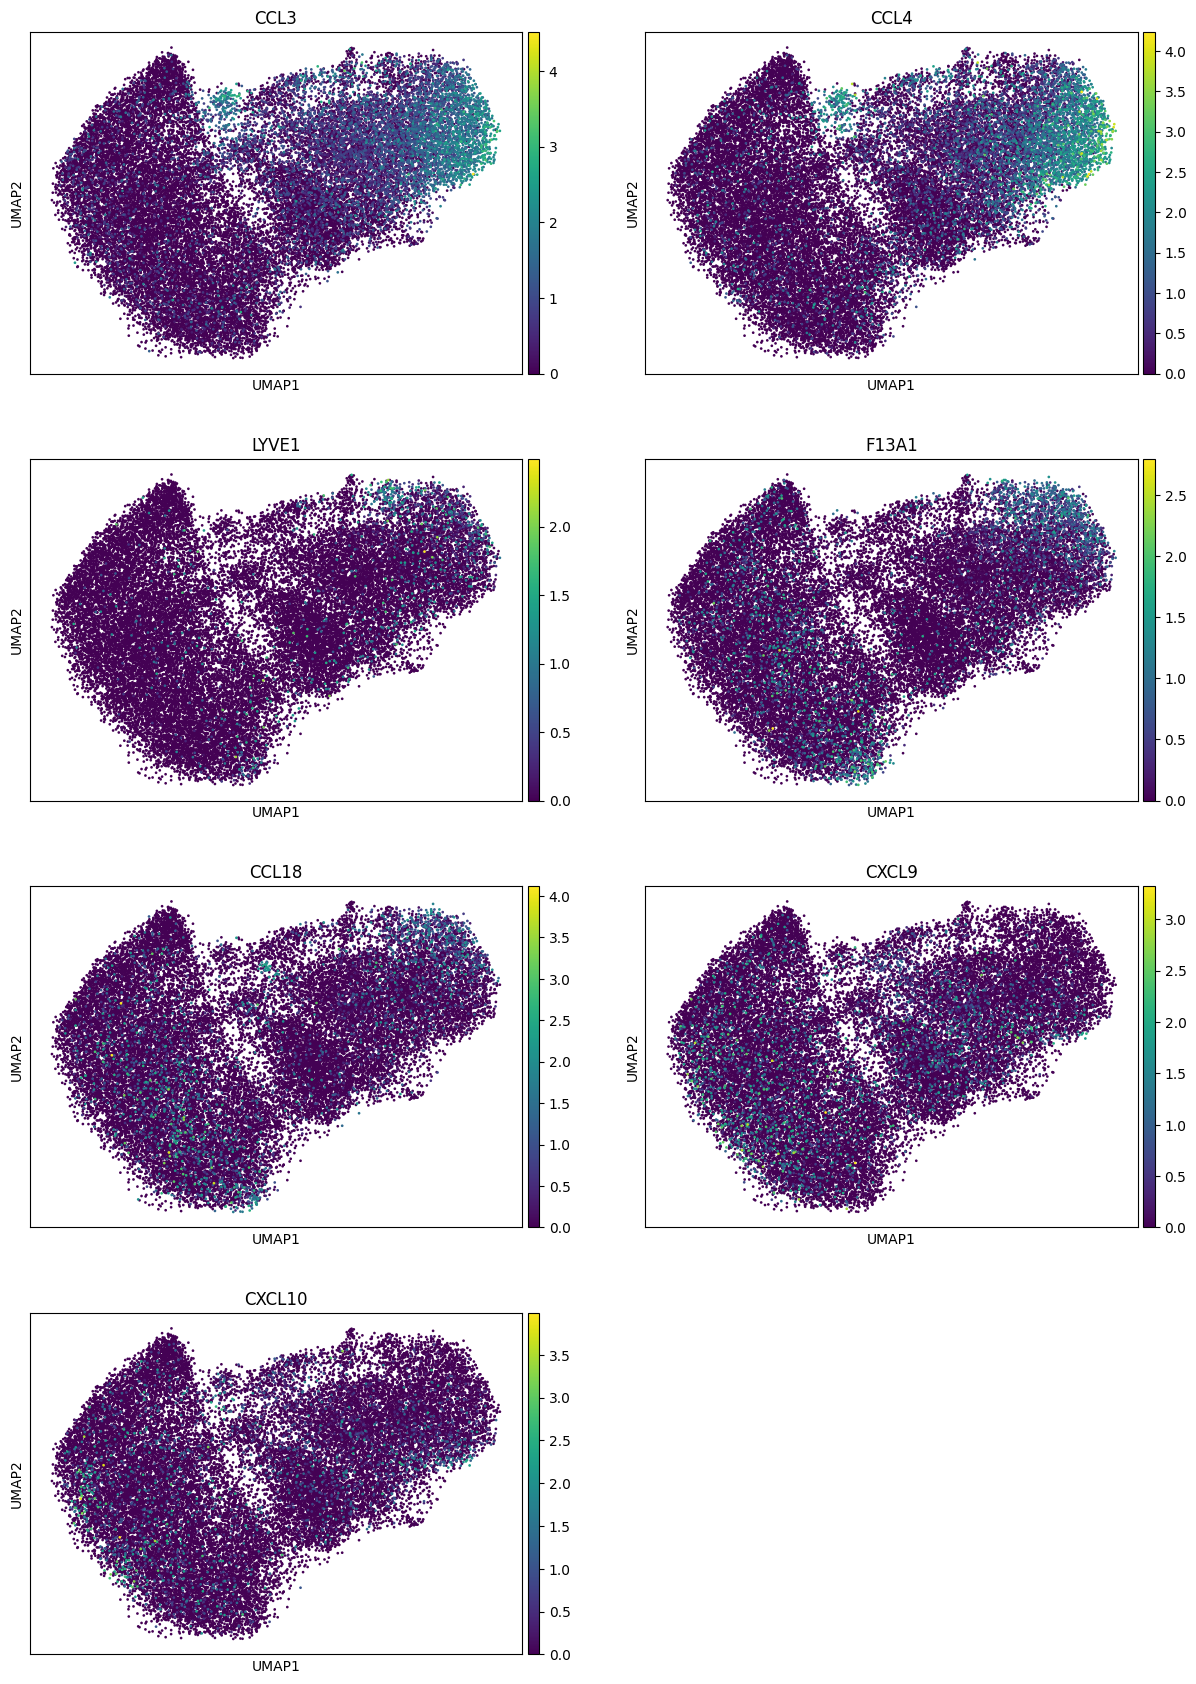

In [22]:
sc.pl.umap(adata_macrophages, color=["CCL3", "CCL4", "LYVE1", "F13A1", "CCL18", "CXCL9", "CXCL10"], ncols=2, size=15, use_raw=False)

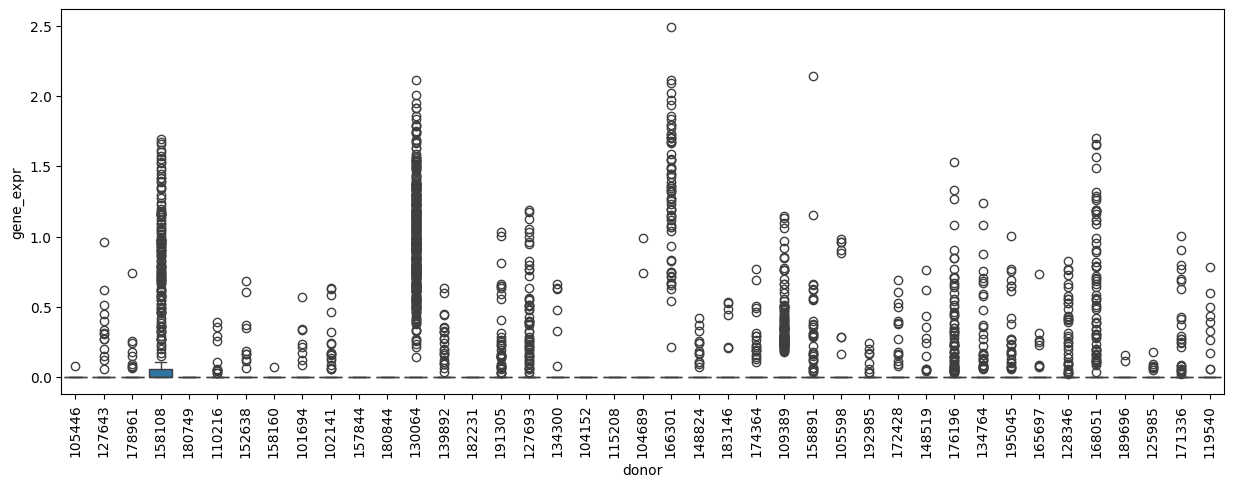

In [23]:
data = {"gene_expr": [], "donor": []}
col = "donor_id"

for donor in adata_macrophages.obs[col].unique():
    gene_expr = adata_macrophages[
        adata_macrophages.obs[col] == donor, "LYVE1"
    ].X.toarray().flatten().tolist()
    data["gene_expr"] += gene_expr
    data["donor"] += [donor] * len(gene_expr)


data = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(15, 5))
ax = sns.boxplot(
    x="donor",
    y="gene_expr",
    data=data,
)
ax.tick_params(axis='x', labelrotation=90)

In [24]:
data.groupby("donor")["gene_expr"].mean().sort_values(ascending=False).to_frame()

,gene_expr
donor,
158108,0.210454
130064,0.080607
109389,0.043600
102141,0.029359
168051,0.026658
166301,0.024935
152638,0.023777
174364,0.023102
176196,0.022756
